# Practice 05 — ML General Tips

Three questions that come up after a model is trained.

| Question | Tool |
|:---|:---|
| Is accuracy telling me the truth? | confusion matrix, precision / recall, ROC |
| How much of the variation does my regression explain? | $R^2$ |
| Why is it wrong — too simple, or too unstable? | bias–variance decomposition |

---
## Imports

In [1]:
import os
os.environ['OMP_NUM_THREADS'] = '1'   # must be set before sklearn is imported

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.datasets import load_diabetes, load_digits, make_friedman1
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import Ridge, LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (accuracy_score, confusion_matrix, ConfusionMatrixDisplay,
                             precision_score, recall_score, f1_score,
                             roc_curve, roc_auc_score, r2_score)

np.random.seed(42)
plt.rcParams['axes.unicode_minus'] = False

---
# 1. Classification Metrics

## The Whole Evaluation in One Cell

A binary task built from `digits`: **is this image a 3?** About one image in ten is.

Train, infer, score — the complete evaluation, in one place.
Every section after this unpacks one line of it.

accuracy  0.9889
precision 0.9459
recall    0.9459
f1        0.9459
roc auc   0.9982


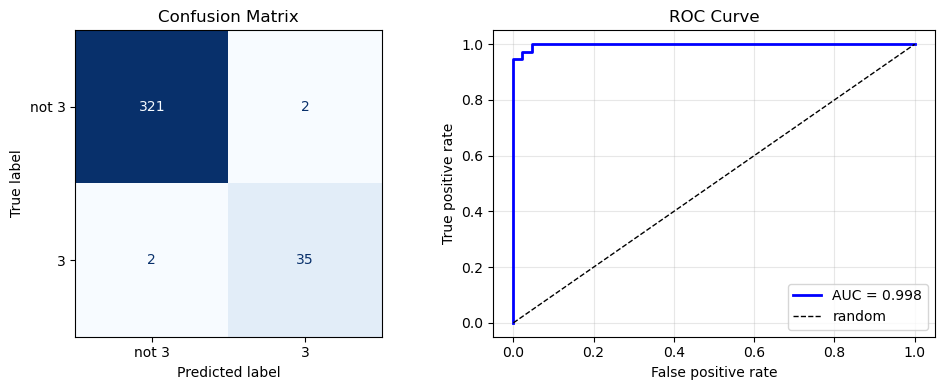

In [2]:
# ---- data
digits = load_digits()
y_binary = (digits.target == 3).astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    digits.data, y_binary, test_size=0.2, random_state=42, stratify=y_binary)

# ---- training
model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, random_state=42))
model.fit(X_train, y_train)

# ---- inference
y_pred = model.predict(X_test)                # labels, thresholded at 0.5
score  = model.predict_proba(X_test)[:, 1]    # the probability behind that threshold

# ---- metrics
print(f'accuracy  {accuracy_score(y_test, y_pred):.4f}')
print(f'precision {precision_score(y_test, y_pred):.4f}')
print(f'recall    {recall_score(y_test, y_pred):.4f}')
print(f'f1        {f1_score(y_test, y_pred):.4f}')
print(f'roc auc   {roc_auc_score(y_test, score):.4f}')

# ---- the two standard plots
matrix = confusion_matrix(y_test, y_pred)
false_positive_rate, true_positive_rate, thresholds = roc_curve(y_test, score)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ConfusionMatrixDisplay(matrix, display_labels=['not 3', '3']).plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix')
axes[1].plot(false_positive_rate, true_positive_rate, 'b-', linewidth=2,
             label=f'AUC = {roc_auc_score(y_test, score):.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, label='random')
axes[1].set_xlabel('False positive rate'); axes[1].set_ylabel('True positive rate')
axes[1].set_title('ROC Curve'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

---
## Why Accuracy Alone Is Not Enough

Only one image in ten is a 3, so a classifier that always answers "no" already looks good.

In [3]:
print(f'test set: {np.bincount(y_test)}  ->  {y_test.mean():.1%} positive')

always_negative = np.zeros_like(y_test)
print(f'\nalways-negative accuracy : {accuracy_score(y_test, always_negative):.4f}')
print(f'always-negative recall   : {recall_score(y_test, always_negative):.4f}')

test set: [323  37]  ->  10.3% positive

always-negative accuracy : 0.8972
always-negative recall   : 0.0000


Nearly 90% accurate, and it never finds a single 3.
Accuracy counts every sample equally, so on an imbalanced problem the majority class decides it.
That is why the other metrics exist.

---
## Confusion Matrix, Precision, Recall

| | predicted 0 | predicted 1 |
|:---|:---|:---|
| **actual 0** | TN | FP (false alarm) |
| **actual 1** | FN (missed) | TP |

$$\text{precision} = \frac{TP}{TP + FP}, \qquad
\text{recall} = \frac{TP}{TP + FN}, \qquad F_1 = \frac{2 \cdot \text{precision} \cdot
\text{recall}}{\text{precision} + \text{recall}}$$

| Metric | A low value means |
|:---|:---|
| precision | false alarms |
| recall | misses |
| F1 | at least one of the two is bad |

Which matters depends on the cost: a missed crack in a turbine blade is not an unnecessary inspection.

In [4]:
tn, fp, fn, tp = matrix.ravel()

print(f'tn {tn}   fp {fp}   fn {fn}   tp {tp}')
print(f'precision {precision_score(y_test, y_pred):.4f}   = tp/(tp+fp) = {tp}/{tp + fp}')
print(f'recall    {recall_score(y_test, y_pred):.4f}   = tp/(tp+fn) = {tp}/{tp + fn}')

tn 321   fp 2   fn 2   tp 35
precision 0.9459   = tp/(tp+fp) = 35/37
recall    0.9459   = tp/(tp+fn) = 35/37


For more than two classes, `average='macro'` computes each metric per class and averages them, so a rare
class counts as much as a common one.

---
## ROC and AUC

`accuracy`, `precision` and `recall` all judged the *labels*, and those came from a hidden decision:
`predict` calls anything above **0.5** a 3.
AUC judges the `score` instead, so it does not depend on that choice.

For comparison, a second model that sees only two of the 64 pixels.
Nothing else differs.

In [5]:
two_pixels = [21, 42]
model_two_pixels = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, random_state=42))
model_two_pixels.fit(X_train[:, two_pixels], y_train)
score_two_pixels = model_two_pixels.predict_proba(X_test[:, two_pixels])[:, 1]

for name, values in [('64 pixels', score), ('2 pixels', score_two_pixels)]:
    predicted = (values >= 0.5).astype(int)
    print(f'{name:10s} AUC {roc_auc_score(y_test, values):.4f}   '
          f'at threshold 0.5: accuracy {accuracy_score(y_test, predicted):.4f}, '
          f'precision {precision_score(y_test, predicted, zero_division=0):.4f}, '
          f'recall {recall_score(y_test, predicted):.4f}')

64 pixels  AUC 0.9982   at threshold 0.5: accuracy 0.9889, precision 0.9459, recall 0.9459
2 pixels   AUC 0.8161   at threshold 0.5: accuracy 0.8972, precision 0.0000, recall 0.0000


The 2-pixel model has **AUC 0.82** — clearly better than guessing — yet at the default threshold its
precision and recall are both **zero**, and its accuracy is 0.8972: exactly the always-negative classifier
from the start.
None of its scores reach 0.5, so it never says "3".

Two different things are being measured.
The next plot separates them.

---
## Reading AUC from the Score Distributions

The histograms below show each model's predicted score, separately for the true 0s and the true 1s.
A classifier is good exactly when those two distributions are **far apart**; a threshold is a vertical line
through them.

$$\text{AUC} = P\bigl(\,\text{score of a random positive} > \text{score of a random negative}\,\bigr)$$

No overlap → AUC 1.0; distributions on top of each other → 0.5.
Sliding the threshold traces the **ROC curve**, and AUC is the area under it — the code below checks that
equality by counting pairs.

In [6]:
# AUC as a probability: count every (positive, negative) pair and ask who scored higher
for name, values in [('64 pixels', score), ('2 pixels', score_two_pixels)]:
    positives, negatives = values[y_test == 1], values[y_test == 0]
    wins = (positives[:, None] > negatives[None, :]).mean()
    ties = (positives[:, None] == negatives[None, :]).mean()
    print(f'{name:10s} pairwise P(positive > negative) : {wins + 0.5 * ties:.6f}')
    print(f'{"":10s} roc_auc_score                    : {roc_auc_score(y_test, values):.6f}')

64 pixels  pairwise P(positive > negative) : 0.998159
           roc_auc_score                    : 0.998159
2 pixels   pairwise P(positive > negative) : 0.816124
           roc_auc_score                    : 0.816124


---
## Marking a Threshold on the Curve

Every point of the ROC curve *is* a threshold.
Two common ways to pick one:

- **Youden's J** — maximise $TPR - FPR$, the point farthest above the diagonal.
- **max F1** — maximise the balance of precision and recall.

They disagree, because they optimise different things.
Both are marked below.

In [7]:
false_positive_rate_64, true_positive_rate_64, thresholds_64 = roc_curve(y_test, score)
auc_64 = roc_auc_score(y_test, score)

# Youden's J is defined as argmax(TPR - FPR), so the formula is the code
youden = thresholds_64[np.argmax(true_positive_rate_64 - false_positive_rate_64)]

# the max-F1 threshold needs one F1 score per candidate threshold
f1_values = []
for threshold in thresholds_64:
    predicted = (score >= threshold).astype(int)
    f1_values.append(f1_score(y_test, predicted, zero_division=0))
best_f1 = thresholds_64[np.argmax(f1_values)]

print(f'64 pixels: Youden threshold {youden:.3f}, max-F1 threshold {best_f1:.3f}')

64 pixels: Youden threshold 0.053, max-F1 threshold 0.809


In [8]:
# the same three steps for the 2-pixel model
false_positive_rate_2, true_positive_rate_2, thresholds_2 = roc_curve(y_test, score_two_pixels)
auc_2 = roc_auc_score(y_test, score_two_pixels)

youden_two_pixels = thresholds_2[np.argmax(true_positive_rate_2 - false_positive_rate_2)]

f1_values_two_pixels = []
for threshold in thresholds_2:
    predicted = (score_two_pixels >= threshold).astype(int)
    f1_values_two_pixels.append(f1_score(y_test, predicted, zero_division=0))
best_f1_two_pixels = thresholds_2[np.argmax(f1_values_two_pixels)]

print(f'2 pixels : Youden threshold {youden_two_pixels:.3f}, max-F1 threshold {best_f1_two_pixels:.3f}')

2 pixels : Youden threshold 0.177, max-F1 threshold 0.191


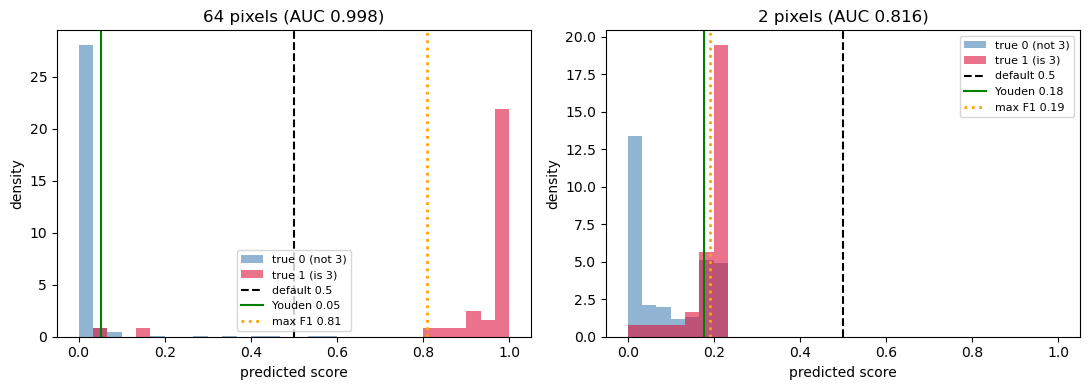

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
bins = np.linspace(0, 1, 31)

axes[0].hist(score[y_test == 0], bins=bins, alpha=0.6, density=True,
             color='steelblue', label='true 0 (not 3)')
axes[0].hist(score[y_test == 1], bins=bins, alpha=0.6, density=True,
             color='crimson', label='true 1 (is 3)')
axes[0].axvline(0.5, color='k', linestyle='--', linewidth=1.5, label='default 0.5')
axes[0].axvline(youden, color='green', linestyle='-', linewidth=1.5, label=f'Youden {youden:.2f}')
axes[0].axvline(best_f1, color='orange', linestyle=':', linewidth=2, label=f'max F1 {best_f1:.2f}')
axes[0].set_xlabel('predicted score'); axes[0].set_ylabel('density')
axes[0].set_title(f'64 pixels (AUC {auc_64:.3f})')
axes[0].legend(fontsize=8)

axes[1].hist(score_two_pixels[y_test == 0], bins=bins, alpha=0.6, density=True,
             color='steelblue', label='true 0 (not 3)')
axes[1].hist(score_two_pixels[y_test == 1], bins=bins, alpha=0.6, density=True,
             color='crimson', label='true 1 (is 3)')
axes[1].axvline(0.5, color='k', linestyle='--', linewidth=1.5, label='default 0.5')
axes[1].axvline(youden_two_pixels, color='green', linestyle='-', linewidth=1.5,
                label=f'Youden {youden_two_pixels:.2f}')
axes[1].axvline(best_f1_two_pixels, color='orange', linestyle=':', linewidth=2,
                label=f'max F1 {best_f1_two_pixels:.2f}')
axes[1].set_xlabel('predicted score'); axes[1].set_ylabel('density')
axes[1].set_title(f'2 pixels (AUC {auc_2:.3f})')
axes[1].legend(fontsize=8)

plt.tight_layout(); plt.show()

The same two models as ROC curves.
Every point on a curve is one threshold, and the area under the curve is the AUC printed above.

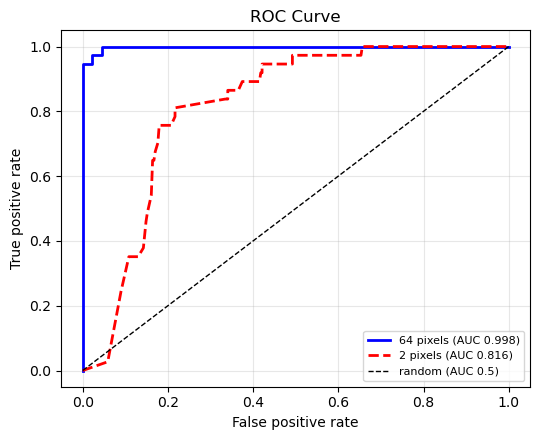

In [10]:
fig, ax = plt.subplots(figsize=(5.5, 4.5))
ax.plot(false_positive_rate_64, true_positive_rate_64, 'b-', linewidth=2,
        label=f'64 pixels (AUC {auc_64:.3f})')
ax.plot(false_positive_rate_2, true_positive_rate_2, 'r--', linewidth=2,
        label=f'2 pixels (AUC {auc_2:.3f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='random (AUC 0.5)')
ax.set_xlabel('False positive rate'); ax.set_ylabel('True positive rate')
ax.set_title('ROC Curve'); ax.legend(fontsize=8, loc='lower right'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [11]:
threshold_rules = [
    ('64 pixels', score, 'default 0.5', 0.5),
    ('64 pixels', score, 'Youden', youden),
    ('64 pixels', score, 'max F1', best_f1),
    ('2 pixels', score_two_pixels, 'default 0.5', 0.5),
    ('2 pixels', score_two_pixels, 'Youden', youden_two_pixels),
    ('2 pixels', score_two_pixels, 'max F1', best_f1_two_pixels),
]

rows = []
for name, values, rule, threshold in threshold_rules:
    predicted = (values >= threshold).astype(int)
    rows.append({'model': name, 'rule': rule, 'threshold': threshold,
                 'accuracy':  accuracy_score(y_test, predicted),
                 'precision': precision_score(y_test, predicted, zero_division=0),
                 'recall':    recall_score(y_test, predicted),
                 'f1':        f1_score(y_test, predicted, zero_division=0)})
display(pd.DataFrame(rows).round(3))

,model,rule,threshold,accuracy,precision,recall,f1
0,64 pixels,default 0.5,0.500,0.989,0.946,0.946,0.946
1,64 pixels,Youden,0.053,0.958,0.712,1.000,0.831
2,64 pixels,max F1,0.809,0.994,1.000,0.946,0.972
3,2 pixels,default 0.5,0.500,0.897,0.000,0.000,0.000
4,2 pixels,Youden,0.177,0.786,0.300,0.811,0.438
5,2 pixels,max F1,0.191,0.814,0.326,0.757,0.455


- **64-pixel model** — distributions at opposite ends, almost no overlap; the ROC hugs the corner.
- **2-pixel model** — heavy overlap, but the red one is shifted right (0.19 against 0.09), and that shift is
  the whole of its AUC 0.82.
  Both sit below 0.5, which is why the default threshold produced nothing and why moving it to 0.18 catches
  four out of five 3s.

- **"Optimal" depends on what you optimise.** Youden maximises $TPR - FPR$ and ignores how rare the
  positives are, so on the 64-pixel model it *lowers* accuracy and F1.

**AUC is about ranking, not deciding** — it does not move when the cut-off does.

---
# 2. Regression Metrics — $R^2$

## Three Levels of Fit

Nothing here is right or wrong to count.
The question is how much of the variation in $y$ the model accounts for:

$$R^2 = 1 - \frac{SSE}{SST}, \qquad SSE = \sum_i (y_i - \hat{y}_i)^2, \qquad SST = \sum_i (y_i - \bar{y})^2$$

$SSE$ is what is left unexplained, $SST$ is what there was to explain.
So 1 is a perfect fit and 0 is the score of always predicting the mean.

Three datasets from the **same straight line**, differing only in the noise added.

In [12]:
def noisy_line(noise_std, n_samples=120, seed=42):
    # same line y = 5 + 2x every time; only the noise changes
    rng = np.random.RandomState(seed)
    x = rng.uniform(-3, 3, (n_samples, 1))
    y = 5.0 + 2.0 * x[:, 0] + rng.normal(0, noise_std, n_samples)
    return x, y


cases = {'low noise': 1.15, 'medium noise': 2.0, 'high noise': 3.5}
datasets = {name: noisy_line(noise_std) for name, noise_std in cases.items()}

for name, (x, y) in datasets.items():
    print(f'{name:14s} noise std {cases[name]:.2f}, {len(y)} samples')

low noise      noise std 1.15, 120 samples
medium noise   noise std 2.00, 120 samples
high noise     noise std 3.50, 120 samples


---
## Computing $R^2$ by Hand

For the cleanest of the three, the definition and the library give the same number.

In [13]:
x, y = datasets['low noise']

fitted = LinearRegression()
fitted.fit(x, y)
y_hat = fitted.predict(x)

SST = ((y - y.mean()) ** 2).sum()
SSE = ((y - y_hat) ** 2).sum()

print(f'SST            {SST:10.2f}')
print(f'SSE            {SSE:10.2f}')
print(f'1 - SSE/SST    {1 - SSE / SST:10.6f}')
print(f'r2_score       {r2_score(y, y_hat):10.6f}')

SST               1603.84
SSE                151.94
1 - SSE/SST      0.905262
r2_score         0.905262


From here on, `r2_score`.

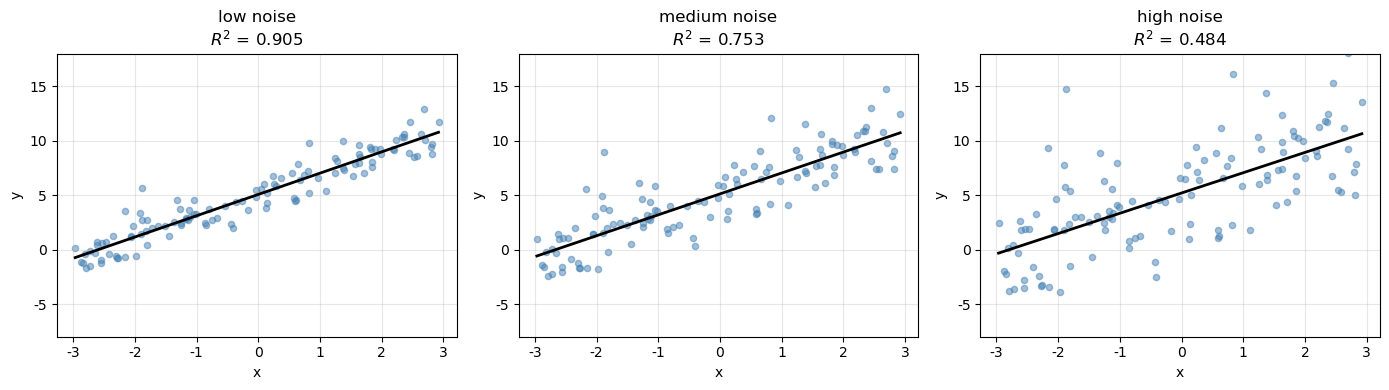

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (name, (x, y)) in zip(axes, datasets.items()):
    fitted = LinearRegression()
    fitted.fit(x, y)
    y_hat = fitted.predict(x)
    order = np.argsort(x[:, 0])
    ax.scatter(x, y, s=20, alpha=0.5, c='steelblue')
    ax.plot(x[order], y_hat[order], 'k-', linewidth=2)
    ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.set_title(f'{name}\n$R^2$ = {r2_score(y, y_hat):.3f}')
    ax.set_ylim(-8, 18)
    ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()

The line is the same in all three panels; only the scatter around it changes.
$R^2$ measures how tightly the points hold to the fit, not whether the fit has the right shape — the model
is exactly right in all three, so **a low $R^2$ does not mean a wrong model.**

On test data it can go **negative**, when $SSE > SST$: worse than predicting the mean.

---
# 3. Bias and Variance

## The Decomposition

Train the same model on many different training sets.
At one test point its predictions form a distribution, and the expected squared error splits in two:

$$\mathbb{E}\bigl[(y - \hat{y})^2\bigr] = \underbrace{\bigl(y - \mathbb{E}[\hat{y}]\bigr)^2}_{\text{bias}^2}
+ \underbrace{\mathbb{E}\bigl[(\hat{y} - \mathbb{E}[\hat{y}])^2\bigr]}_{\text{variance}}$$

| Term | Means | Cause |
|:---|:---|:---|
| bias² | the average prediction is off | too rigid; more data will not help |
| variance | the prediction moves with the training set | too flexible; it is fitting noise |

Complexity trades one for the other, so the total has a minimum in between.
Lacking many training sets, we **bootstrap**: resample with replacement, refit, and use the spread of
predictions.

In [15]:
def bias_variance_decomposition(estimator, X_train, y_train, X_test, y_reference, n_rounds=40, seed=42):
    # refit on n_rounds bootstrap resamples and split the squared error at each test point
    rng = np.random.RandomState(seed)
    predictions = np.zeros((n_rounds, len(X_test)))

    for r in range(n_rounds):
        index = rng.randint(0, len(X_train), len(X_train))    # sample with replacement
        refitted = clone(estimator)
        refitted.fit(X_train[index], y_train[index])
        predictions[r] = refitted.predict(X_test)

    mean_prediction = predictions.mean(axis=0)
    bias_squared = np.mean((y_reference - mean_prediction) ** 2)
    variance     = np.mean(predictions.var(axis=0))
    return bias_squared, variance

---
## The Trade-off

On real data, noise cannot be separated from bias — both push the average prediction away from the observed
value.
So we use `make_friedman1`, whose noiseless form is known, and score against it.

Complexity is the depth of a regression tree.

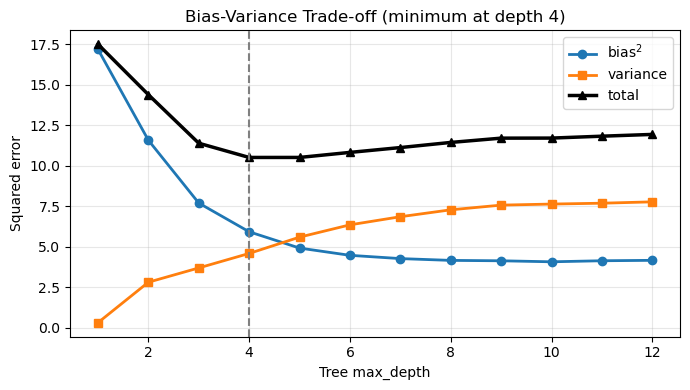

depth  1: bias^2  17.19  variance  0.32
depth  4: bias^2   5.92  variance  4.59   <- minimum
depth 12: bias^2   4.16  variance  7.77


In [16]:
X_friedman, y_friedman = make_friedman1(n_samples=600, n_features=10, noise=1.0, random_state=0)

def friedman_truth(X):
    return 10 * np.sin(np.pi * X[:, 0] * X[:, 1]) + 20 * (X[:, 2] - 0.5) ** 2 + 10 * X[:, 3] + 5 * X[:, 4]

X_train_friedman, X_test_friedman, y_train_friedman, _ = train_test_split(
    X_friedman, y_friedman, test_size=0.3, random_state=0)
y_true_friedman = friedman_truth(X_test_friedman)

depths = range(1, 13)
bias_curve, variance_curve = [], []
for depth in depths:
    bias_squared, variance = bias_variance_decomposition(
        DecisionTreeRegressor(max_depth=depth, random_state=0),
        X_train_friedman, y_train_friedman, X_test_friedman, y_true_friedman)
    bias_curve.append(bias_squared)
    variance_curve.append(variance)

total_curve = np.array(bias_curve) + np.array(variance_curve)
best_depth = list(depths)[int(np.argmin(total_curve))]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(depths, bias_curve, 'o-', linewidth=2, label='bias$^2$')
ax.plot(depths, variance_curve, 's-', linewidth=2, label='variance')
ax.plot(depths, total_curve, 'k^-', linewidth=2.5, label='total')
ax.axvline(best_depth, color='gray', linestyle='--', linewidth=1.5)
ax.set_xlabel('Tree max_depth'); ax.set_ylabel('Squared error')
ax.set_title(f'Bias-Variance Trade-off (minimum at depth {best_depth})')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f'depth  1: bias^2 {bias_curve[0]:6.2f}  variance {variance_curve[0]:5.2f}')
print(f'depth {best_depth:2d}: bias^2 {bias_curve[best_depth - 1]:6.2f}  variance {variance_curve[best_depth - 1]:5.2f}   <- minimum')
print(f'depth 12: bias^2 {bias_curve[-1]:6.2f}  variance {variance_curve[-1]:5.2f}')

Bias² falls and then flattens — past some depth the tree can already represent the function.
Variance keeps rising, because deeper trees split the sample into smaller regions decided by fewer points.
The sum turns back up: that is overfitting, and the training error will not show it.

---
## Two Remedies

The same function on `diabetes` — 442 patients, ten measurements, a noisy target.

The truth is unknown here, so the irreducible noise sits inside bias². Only the **variance** column compares
cleanly across models.

In [17]:
diabetes = load_diabetes()
X_train_diabetes, X_test_diabetes, y_train_diabetes, y_test_diabetes = train_test_split(
    diabetes.data, diabetes.target, test_size=0.3, random_state=0)

candidates = {
    'Tree (max_depth=2)':  DecisionTreeRegressor(max_depth=2, random_state=0),
    'Tree (unlimited)':    DecisionTreeRegressor(random_state=0),
    'Ridge (alpha=5)':     make_pipeline(StandardScaler(), Ridge(alpha=5.0)),
    'Random Forest (100)': RandomForestRegressor(n_estimators=100, random_state=0, n_jobs=-1),
}

rows = []
for name, estimator in candidates.items():
    bias_squared, variance = bias_variance_decomposition(
        estimator, X_train_diabetes, y_train_diabetes, X_test_diabetes, y_test_diabetes)
    rows.append({'model': name, 'bias^2 (+ noise)': bias_squared,
                 'variance': variance, 'total': bias_squared + variance})

display(pd.DataFrame(rows).round(1))

,model,bias^2 (+ noise),variance,total
0,Tree (max_depth=2),3389.5,771.0,4160.5
1,Tree (unlimited),3655.4,3051.6,6707.1
2,Ridge (alpha=5),3112.2,83.4,3195.5
3,Random Forest (100),3399.0,322.3,3721.3


The unlimited tree has four times the variance of the shallow one and no better bias², so it is the worst of
the four.
Both remedies attack variance only: **Ridge** shrinks the coefficients so the fit moves less, **Random
Forest** averages a hundred high-variance trees and cancels most of it.

The bias² column barely moves across all four — that is the noise floor, and no model choice lowers it.

---
## Summary

| Metric | Blind to |
|:---|:---|
| accuracy | class imbalance |
| precision | the ones missed |
| recall | the false alarms |
| ROC AUC | the threshold you deploy |
| $R^2$ | whether the fit has the right shape |

- AUC and the threshold are separate: AUC 0.82 predicted nothing at 0.5, and moving the cut-off fixed it.
- $R^2$ fell 0.91 → 0.48 where the model was equally correct.
  Only the noise changed.
- bias² high → too simple; variance high → fitting noise.